
# Sistema de Recomendación de Películas y Series de Netflix

Este notebook implementa un sistema de recomendación **basado en contenido** utilizando el dataset **netflix_titles.csv**.  
Se emplea procesamiento de lenguaje natural para analizar las descripciones y recomendar títulos similares.



## Introducción

Se trata de un recomendador sencillo basado en contenido. Usaremos la descripción de películas y series para calcular similitudes y sugerir títulos parecidos.



## Importar librerías

Importamos las librerías necesarias para el procesamiento de datos, visualización y cálculo de similitud.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel



## Cargar el dataset

Leemos el archivo CSV que contiene el catálogo de Netflix.


In [2]:

netflix_dataset=pd.read_csv(r'C:\\Users\\poxol\\Documents\\Uni\\ECBD\\Practica09\\DatasetViejo\\netflix_dataset.csv')
netflix_dataset.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...



## Vista preliminar de los datos

Mostramos las primeras filas para revisar la estructura.


In [67]:

netflix_dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7281 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB



## Información del dataset

Identificamos los valores unicos


In [4]:

dict = {}
for i in list(netflix_dataset.columns):
    dict[i] = netflix_dataset[i].value_counts().shape[0]
    
print(pd.DataFrame(dict,index = ["unique count"]).transpose())


              unique count
show_id               7787
type                     2
title                 7787
director              4049
cast                  6831
country                681
date_added            1565
release_year            73
rating                  14
duration               216
listed_in              492
description           7769



## Verificación de valores nulos

Identificamos cuántos valores faltantes hay en cada columna.


In [5]:

print('Table of missing values: ')
print(netflix_dataset.isnull().sum())


Table of missing values: 
show_id            0
type               0
title              0
director        2389
cast             718
country          506
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64


## Análisis de películas vs programas de televisión

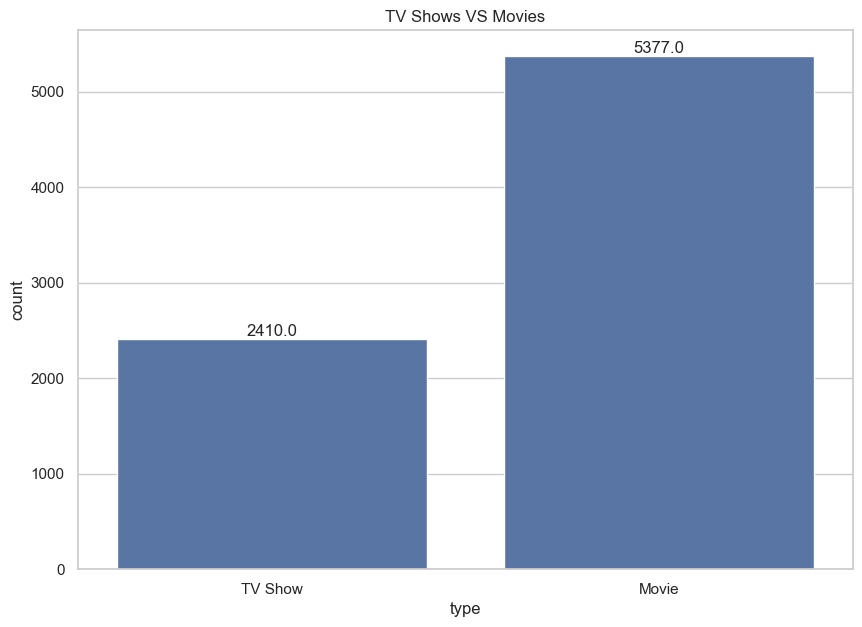

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.set(style='whitegrid')
ax = sns.countplot(x="type", data=netflix_dataset)
ax.set_title("TV Shows VS Movies")

# Agregar los totales encima de las barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2, height), 
                ha='center', va='bottom', fontsize=12)

plt.show()

## ¿En qué mes un productor puede publicar su contenido? (Mes con menor cantidad de contenido añadido)

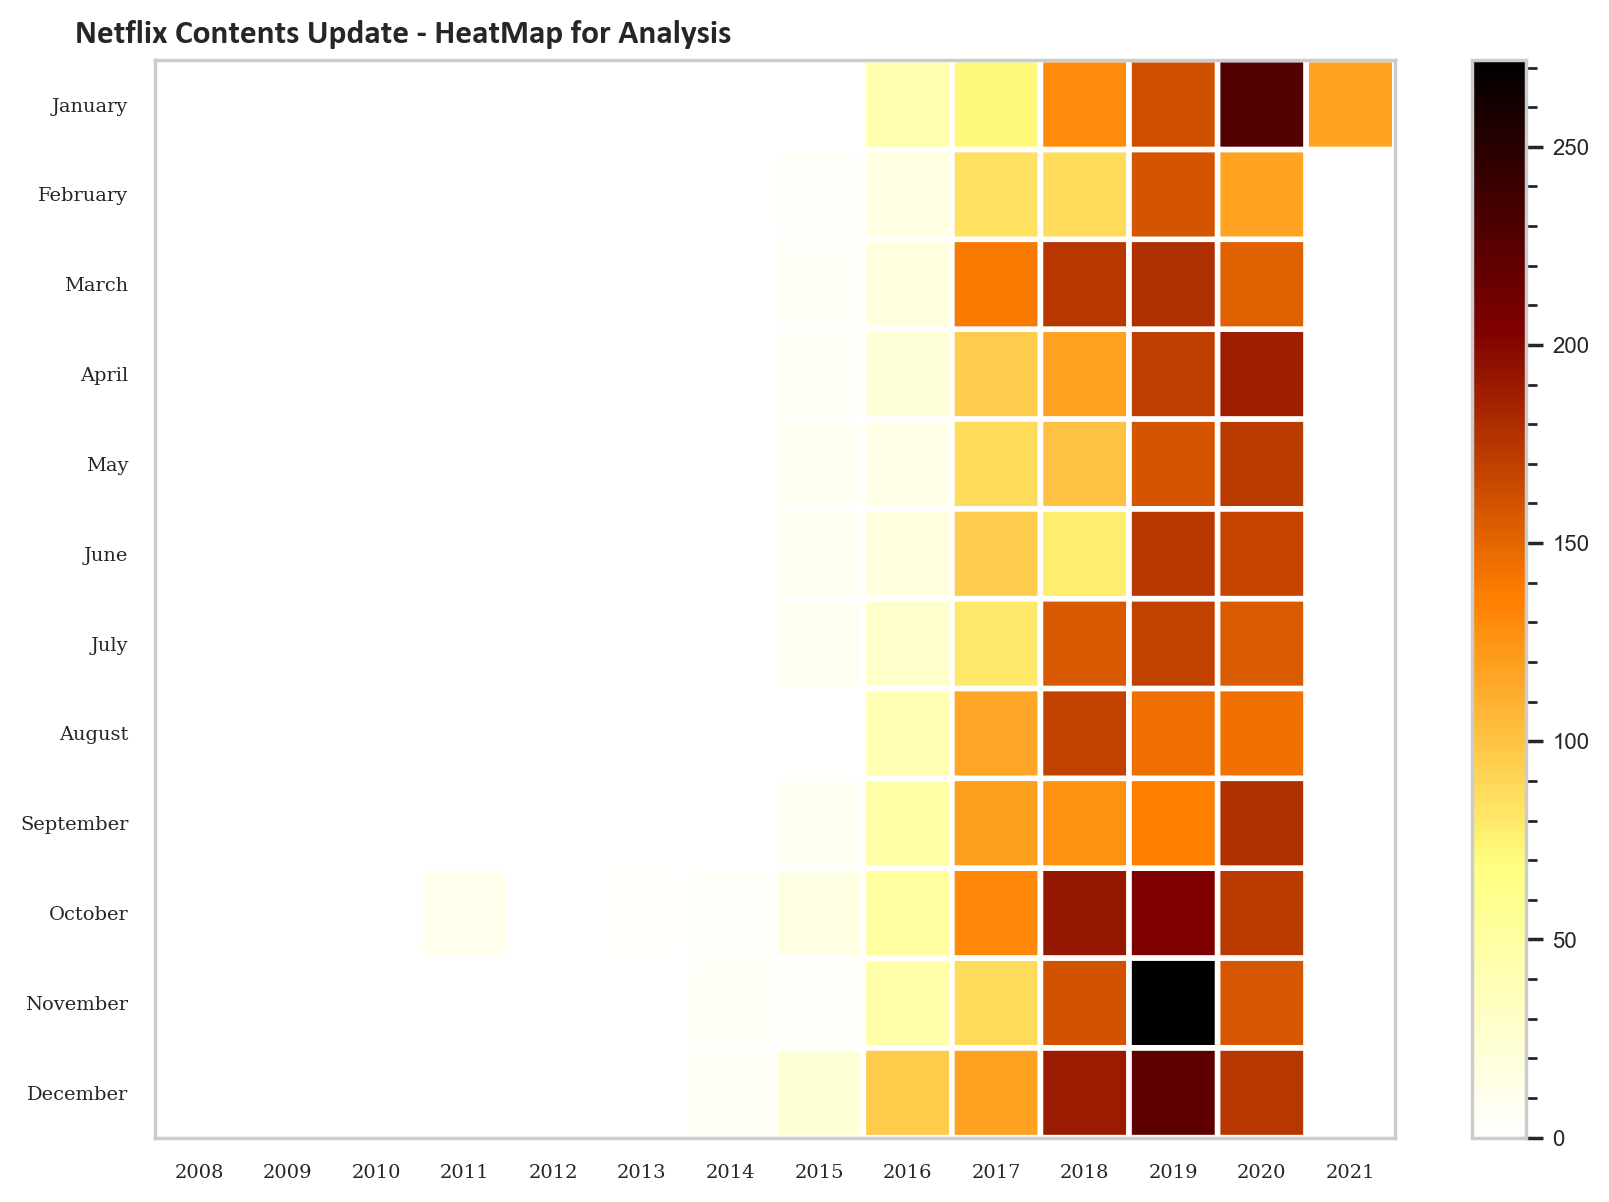

In [7]:
netflix_date = netflix_dataset[['date_added']].dropna()
netflix_date['year'] = netflix_date['date_added'].apply(lambda x: x.split(', ')[-1])
netflix_date['month'] = netflix_date['date_added'].apply(lambda x: x.lstrip().split(' ')[0])

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December'][::-1]

df = netflix_date.groupby('year')['month'].value_counts().unstack().fillna(0)[month_order].T

plt.figure(figsize=(10, 7), dpi=200)
plt.pcolor(df, cmap='afmhot_r', edgecolors='white', linewidths=2)  # heatmap
plt.xticks(np.arange(0.5, len(df.columns), 1), df.columns, fontsize=7, fontfamily='serif')
plt.yticks(np.arange(0.5, len(df.index), 1), df.index, fontsize=7, fontfamily='serif')

plt.title('Netflix Contents Update - HeatMap for Analysis', fontsize=12, fontfamily='calibri', fontweight='bold', position=(0.20, 1.0+0.02))
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=8)
cbar.ax.minorticks_on()
plt.show()


## Análisis de calificaciones de películas

C:\Users\poxol\AppData\Local\Temp\ipykernel_19152\1672330433.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="rating", data=netflix_dataset, palette="Set1", order=netflix_dataset['rating'].value_counts().index[0:15])


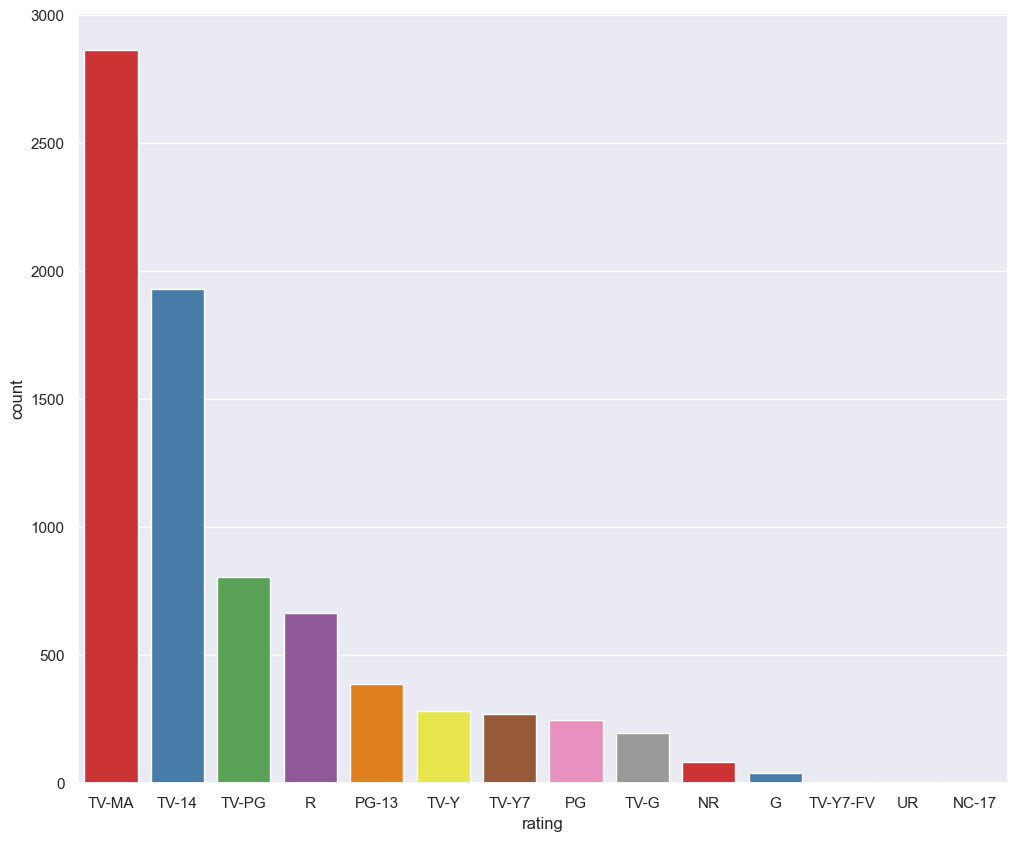

In [8]:
#Analisis de las calificaciones de peliculas
plt.figure(figsize=(12,10))
sns.set(style="darkgrid")
ax = sns.countplot(x="rating", data=netflix_dataset, palette="Set1", order=netflix_dataset['rating'].value_counts().index[0:15])

La mayor cantidad de películas se realizan con la clasificación "TV-MA". "TV-MA" es una clasificación asignada por las Directrices de TV para Padres a programas de televisión diseñados exclusivamente para adultos.

La segunda clasificación más importante es "TV-14", que indica contenido que puede ser inapropiado para niños menores de 14 años.

La tercera clasificación más importante es "TV-PG". Los programas clasificados como "TV-PG" pueden contener material que los padres o tutores consideren inapropiado para niños pequeños. Los programas con clasificación "TV-PG" pueden incluir lenguaje grosero poco frecuente, contenido sexual, diálogos sugerentes o violencia moderada.

## Análisis de las calificaciones de IMDB para obtener las películas mejor valoradas en Netflix

In [68]:
imdb_ratings=pd.read_csv('C:\\Users\\poxol\\Documents\\Uni\\ECBD\\Practica09\\DatasetViejo\\IMDb ratings.csv', usecols=['weighted_average_vote'])
imdb_titles=pd.read_csv('C:\\Users\\poxol\\Documents\\Uni\\ECBD\\Practica09\\DatasetViejo\\IMDb movies.csv', usecols=['title','year','genre'])
ratings = pd.DataFrame({'Title':imdb_titles.title,
                    'Release Year':imdb_titles.year,
                    'Rating': imdb_ratings.weighted_average_vote,
                    'Genre':imdb_titles.genre})
ratings.drop_duplicates(subset=['Title','Release Year','Rating'], inplace=True)
ratings.shape

C:\Users\poxol\AppData\Local\Temp\ipykernel_19152\785683899.py:2: DtypeWarning:

Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.



(85852, 4)

## Realizar una unión interna en el conjunto de datos de calificaciones y el conjunto de datos de Netflix para obtener el contenido que tiene ambas calificaciones en IMDB y está disponible en Netflix.

In [20]:
ratings.dropna()
joint_data=ratings.merge(netflix_dataset,left_on='Title',right_on='title',how='inner')
joint_data=joint_data.sort_values(by='Rating', ascending=False)

## Las 10 películas mejor valoradas en Netflix

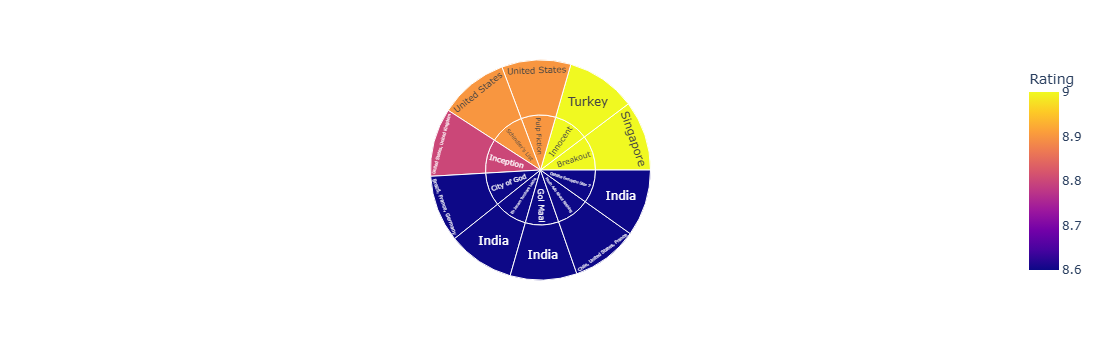

In [21]:
import plotly.express as px
top_rated=joint_data[0:10]
fig =px.sunburst(
    top_rated,
    path=['title','country'],
    values='Rating',
    color='Rating')
fig.show()

## Principales países que crean contenidos

In [22]:
country_count=joint_data['country'].value_counts().sort_values(ascending=False)
country_count=pd.DataFrame(country_count)
topcountries=country_count[0:11]
topcountries

,count
country,
United States,799
India,702
United Kingdom,107
Canada,56
Philippines,50
Spain,40
South Korea,36
Indonesia,35
France,33


## Análisis anual

In [23]:
Last_fifteen_years = netflix_dataset[netflix_dataset['release_year']>2005 ]
Last_fifteen_years.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


C:\Users\poxol\AppData\Local\Temp\ipykernel_19152\4206178935.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




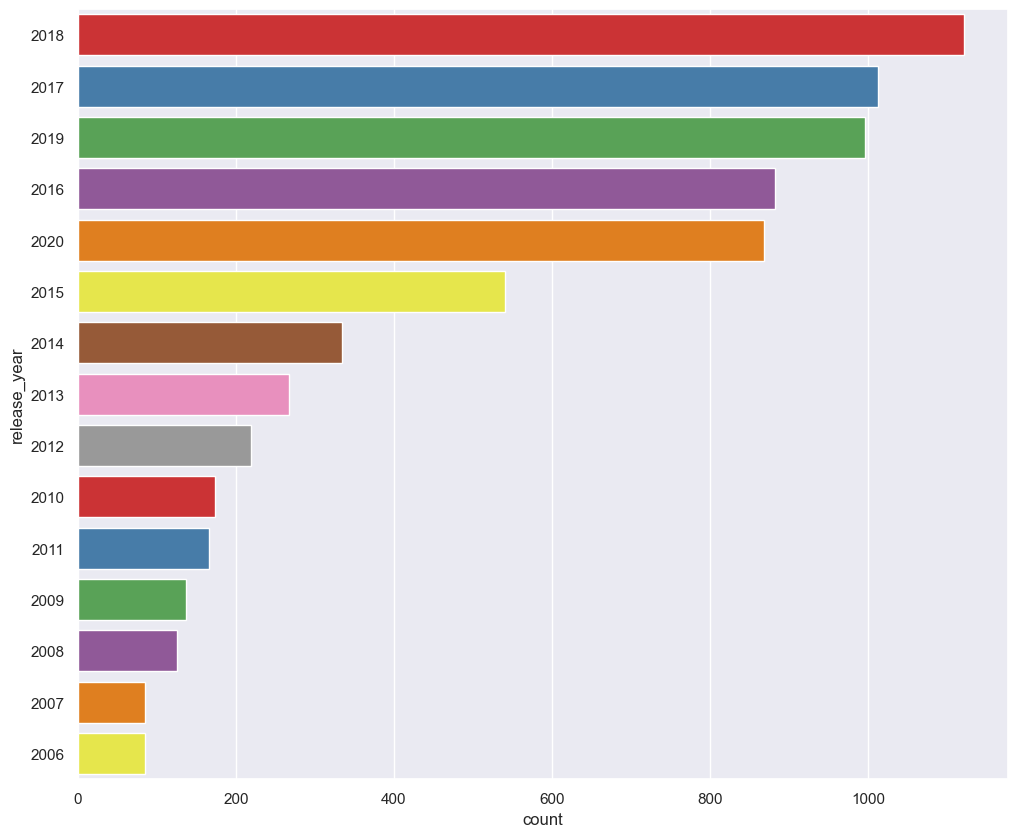

In [24]:
#Análisis anual
plt.figure(figsize=(12,10))
sns.set(style="darkgrid")
ax = sns.countplot(y="release_year", data=Last_fifteen_years, palette="Set1", order=netflix_dataset['release_year'].value_counts().index[0:15])

## Análisis de programas de televisión en Netflix

In [27]:
# Llenar valores nulos con 'Unknown'
netflix_shows = netflix_dataset[netflix_dataset['type'] == 'TV Show'].copy()

netflix_shows['country'] = netflix_shows['country'].fillna('Unknown')

# Crear el diccionario de conteo
countries = {}

# Obtener la lista de valores
country_list = list(netflix_shows['country'])

# Recorrer cada entrada
for entry in country_list:
    # Dividir por comas y quitar espacios
    split_countries = [c.strip() for c in entry.split(',')]
    
    # Contar cada país
    for country in split_countries:
        if country in countries:
            countries[country] += 1
        else:
            countries[country] = 1

# Revisar resultado
countries


{'Brazil': 29,
 'Turkey': 28,
 'Poland': 8,
 'United States': 866,
 'Mexico': 53,
 'Unknown': 276,
 'Japan': 184,
 'South Korea': 157,
 'United Kingdom': 256,
 'India': 75,
 'Canada': 126,
 'Italy': 23,
 'Spain': 57,
 'Australia': 60,
 'Taiwan': 70,
 'China': 45,
 'Germany': 42,
 'France': 84,
 'Singapore': 22,
 'Russia': 17,
 'Mauritius': 1,
 'South Africa': 10,
 'Lebanon': 7,
 'Colombia': 28,
 'Argentina': 18,
 'Philippines': 1,
 'Finland': 4,
 'Netherlands': 8,
 'Chile': 5,
 'Thailand': 22,
 'Nigeria': 8,
 'Saudi Arabia': 4,
 'Syria': 1,
 'Egypt': 13,
 'Kuwait': 3,
 'Belgium': 11,
 'Norway': 9,
 'Sweden': 10,
 'Denmark': 13,
 'Israel': 8,
 'Ireland': 12,
 'Iceland': 2,
 'Indonesia': 3,
 'Malaysia': 8,
 'New Zealand': 8,
 'Czech Republic': 6,
 'Cuba': 1,
 'Austria': 1,
 'Greece': 2,
 'Hong Kong': 5,
 'Pakistan': 4,
 'Luxembourg': 1,
 'Jordan': 1,
 'Uruguay': 1,
 'Azerbaijan': 1,
 'West Germany': 2,
 'Puerto Rico': 1,
 'Malta': 1,
 'Senegal': 1,
 'Ukraine': 2,
 'Switzerland': 1,
 'Bel

In [28]:
countries_fin={}
for country,no in countries.items():
    country=country.replace(' ','')
    if country in list(countries_fin.keys()):
        countries_fin[country]+=no
    else:
        countries_fin[country]=no
        
countries_fin={k: v for k, v in sorted(countries_fin.items(), key=lambda item: item[1], reverse= True)}

C:\Users\poxol\AppData\Local\Temp\ipykernel_19152\3787812420.py:3: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



[Text(0, 0, 'UnitedStates'),
 Text(1, 0, 'Unknown'),
 Text(2, 0, 'UnitedKingdom'),
 Text(3, 0, 'Japan'),
 Text(4, 0, 'SouthKorea'),
 Text(5, 0, 'Canada'),
 Text(6, 0, 'France'),
 Text(7, 0, 'India'),
 Text(8, 0, 'Taiwan'),
 Text(9, 0, 'Australia')]

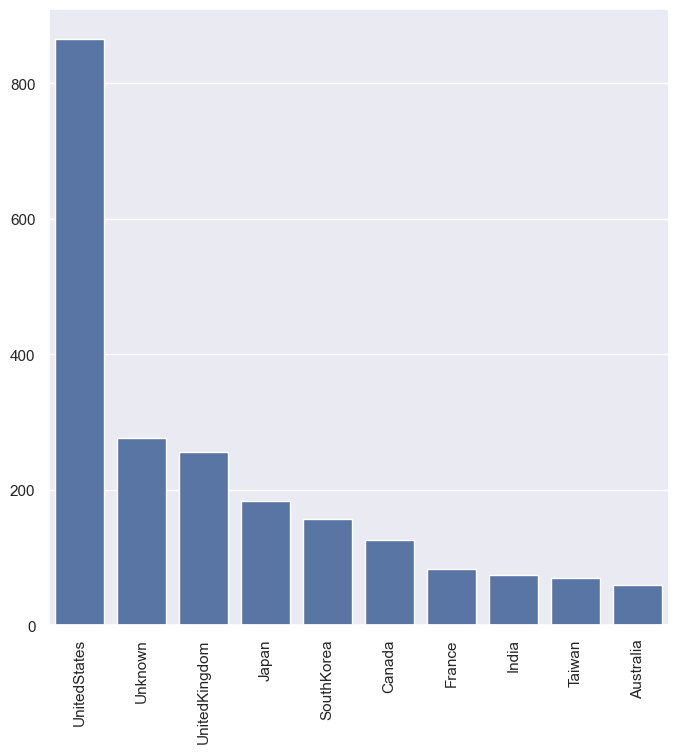

In [69]:

plt.figure(figsize=(8,8))
ax = sns.barplot(x=list(countries_fin.keys())[0:10],y=list(countries_fin.values())[0:10])
ax.set_xticklabels(list(countries_fin.keys())[0:10],rotation = 90)

## Análisis de la duración de las películas

In [71]:
netflix_movies = netflix_dataset[netflix_dataset['type'] == 'Movie'].copy()

netflix_movies['duration']=netflix_movies['duration'].str.replace(' min','')
netflix_movies['duration']=netflix_movies['duration'].astype(str).astype(int)
netflix_movies['duration']

1        93
2        78
3        80
4       123
6        95
       ... 
7781     88
7782     99
7783    111
7784     44
7786     90
Name: duration, Length: 5377, dtype: int32

C:\Users\poxol\AppData\Local\Temp\ipykernel_19152\3136538139.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




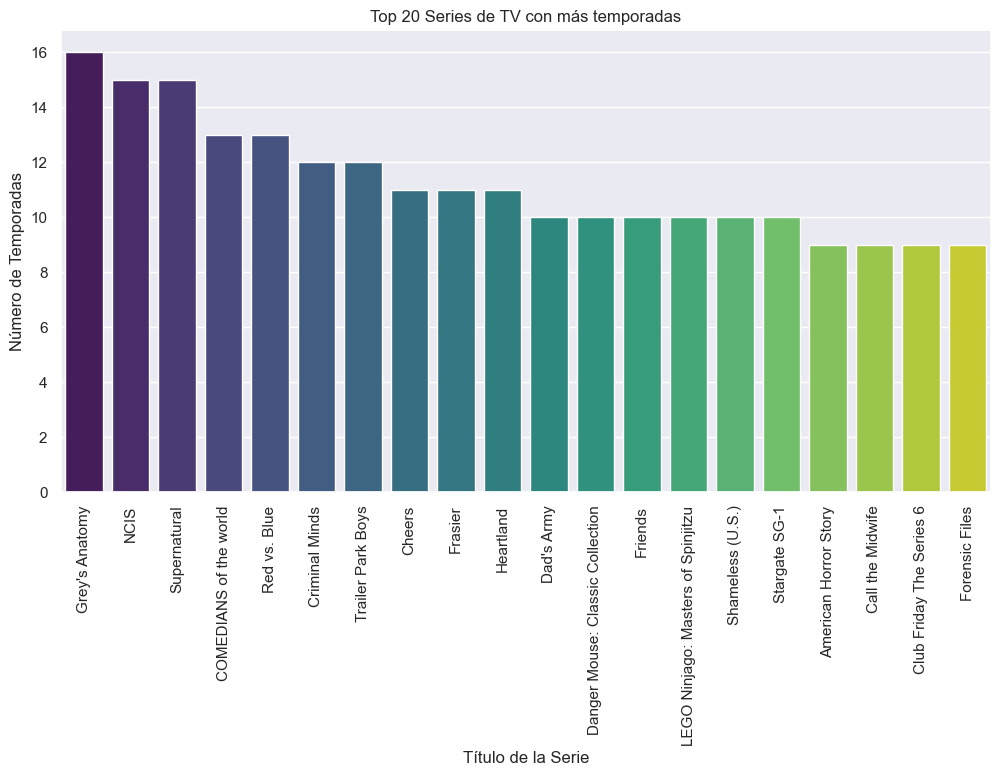

In [72]:
# Filtrar solo Series de TV
netflix_shows = netflix_dataset[netflix_dataset['type'] == 'TV Show'].copy()

# Limpiar la columna 'duration' para extraer el número de temporadas
# Quitar texto como ' Season' o ' Seasons'
netflix_shows['duration'] = netflix_shows['duration'].str.replace(' Seasons','', regex=False)
netflix_shows['duration'] = netflix_shows['duration'].str.replace(' Season','', regex=False)

# Manejar nulos o texto raro
netflix_shows['duration'] = netflix_shows['duration'].fillna('0')
netflix_shows['duration'] = netflix_shows['duration'].astype(int)

# Obtener las 20 series con más temporadas
top20_seasons = netflix_shows.nlargest(20, 'duration')

# Graficar
plt.figure(figsize=(12, 6))
sns.barplot(x='title', y='duration', data=top20_seasons, palette='viridis')
plt.xticks(rotation=90)
plt.title('Top 20 Series de TV con más temporadas')
plt.xlabel('Título de la Serie')
plt.ylabel('Número de Temporadas')
plt.show()

C:\Users\poxol\AppData\Local\Temp\ipykernel_19152\52407833.py:2: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




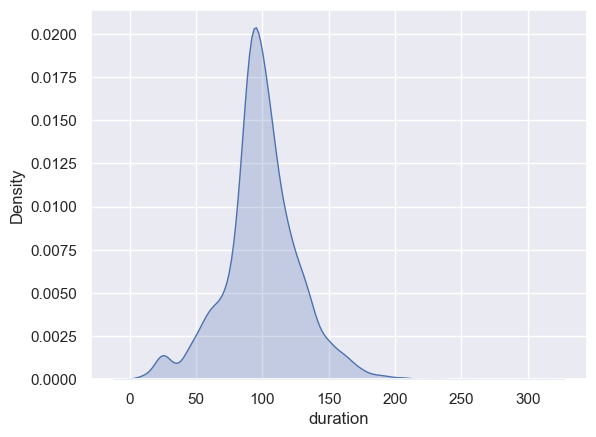

In [32]:
sns.set(style="darkgrid")
ax=sns.kdeplot(data=netflix_movies['duration'], shade=True)

Por lo tanto, una buena cantidad de películas en Netflix tienen una duración de entre 75 y 120 minutos. Es aceptable considerando que una gran parte de la audiencia no puede ver una película de 3 horas de una sola vez.

## Análisis de la duración de los programas de televisión

In [62]:
features=['title','duration']
durations= netflix_shows[features]

durations['no_of_seasons']=durations['duration'].str.replace(' Season','')

#durations['no_of_seasons']=durations['no_of_seasons'].astype(str).astype(int)
durations['no_of_seasons']=durations['no_of_seasons'].str.replace('s','')

C:\Users\poxol\AppData\Local\Temp\ipykernel_19152\315267630.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\poxol\AppData\Local\Temp\ipykernel_19152\315267630.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [63]:
durations['no_of_seasons']=durations['no_of_seasons'].astype(str).astype(int)

C:\Users\poxol\AppData\Local\Temp\ipykernel_19152\4291655225.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [64]:
t=['title','no_of_seasons']
top=durations[t]

top=top.sort_values(by='no_of_seasons', ascending=False)

<Axes: xlabel='title'>

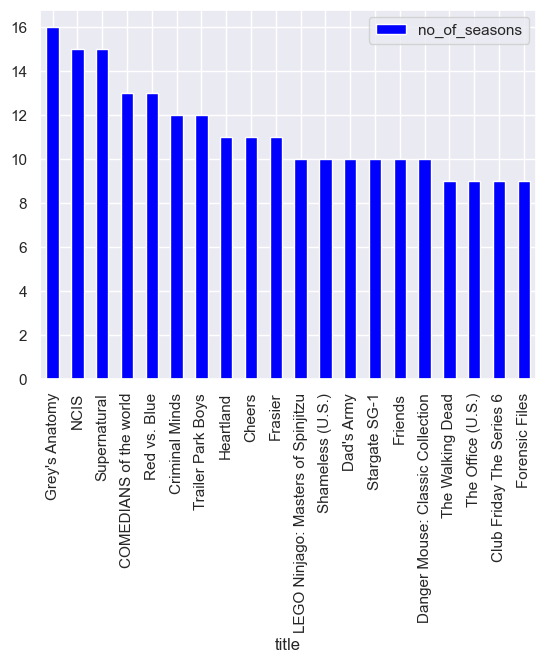

In [65]:
top20=top[0:20]
top20.plot(kind='bar',x='title',y='no_of_seasons', color='blue')

## Sistema de recomendación basado en contenido

In [41]:
#Recomendador basado en descripción de la trama (Recomendaciones basadas en contenido)

netflix_dataset['description'].head()

0    In a future where the elite inhabit an island ...
1    After a devastating earthquake hits Mexico Cit...
2    When an army recruit is found dead, his fellow...
3    In a postapocalyptic world, rag-doll robots hi...
4    A brilliant group of students become card-coun...
Name: description, dtype: object

Calcularemos puntuaciones de similitud por pares para todas las películas según la descripción de sus tramas y recomendaremos películas según dicha puntuación. La descripción de la trama se proporciona en la función de descripción de nuestro conjunto de datos. Analicemos los datos...

Cualquiera que haya realizado algún procesamiento de texto sabe que necesitamos convertir el vector de palabras de cada descripción. Ahora calcularemos los vectores de Frecuencia de Término-Frecuencia Inversa de Documento (TF-IDF) para cada descripción.

La puntuación TF-IDF (Frecuencia de Término-Frecuencia Inversa de Documento (TF-IDF)) es la frecuencia con la que una palabra aparece en un documento, ponderada por el número de documentos en los que aparece. Esto se hace para reducir la importancia de las palabras que aparecen con frecuencia en las vistas generales de la trama y, por lo tanto, su relevancia en el cálculo de la puntuación de similitud final.

Si se pregunta qué es la Frecuencia de Término (TF), es la frecuencia relativa de una palabra en un documento y se expresa como (instancias del término/instancias totales). La Frecuencia Inversa de Documentos (FDI) es el recuento relativo de documentos que contienen el término, expresado como log(número de documentos/documentos con el término). La importancia general de cada palabra para los documentos en los que aparece es igual a TF * FDI.

Esto generará una matriz donde cada columna representa una palabra del vocabulario de descripción (todas las palabras que aparecen en al menos un documento) y cada fila representa una película, como antes. Esto se hace para reducir la importancia de las palabras que aparecen con frecuencia en las descripciones de tramas y, por lo tanto, su relevancia en el cálculo de la puntuación de similitud final.

Afortunadamente, scikit-learn incluye la clase TfIdfVectorizer, que genera la matriz TF-IDF en un par de líneas.

In [66]:
# Sistema de recomendación (basado en contenido)

# Importar TfIdfVectorizer desde scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer

# Definir un objeto vectorizador TF-IDF. Eliminar todas las palabras vacías en inglés, como "the", "a", etc.
tfidf = TfidfVectorizer(stop_words='english')

# Reemplazar NaN con una cadena vacía
netflix_dataset['description'] = netflix_dataset['description'].fillna('')

# Construir la matriz TF-IDF requerida ajustando y transformando los datos
tfidf_matrix = tfidf.fit_transform(netflix_dataset['description'])

# Generar la forma de tfidf_matrix
tfidf_matrix.shape

(7787, 17905)

Con esta matriz en mano, podemos calcular una puntuación de similitud. Existen varias opciones, como la euclidiana, la de Pearson y la del coseno. No hay una respuesta única sobre cuál puntuación es la mejor. Diferentes puntuaciones funcionan bien en diferentes escenarios y suele ser recomendable experimentar con diferentes métricas.

Utilizaremos la similitud del coseno para calcular una cantidad numérica que denota la similitud entre dos películas. Utilizamos la puntuación de similitud del coseno, ya que es independiente de la magnitud y es relativamente fácil y rápida de calcular. Matemáticamente, se define de la siguiente manera:

similitud = cos(x, y) = x . y / ||x|| * ||y||

Como hemos utilizado el vectorizador TF-IDF, calcular el producto escalar nos dará directamente la puntuación de similitud del coseno.

Por lo tanto, utilizaremos la función linear_kernel() de sklearn en lugar de cosine_similarities(), ya que es más rápida.

In [43]:
# Generar la forma de tfidf_matrix
from sklearn.metrics.pairwise import linear_kernel

# Calcular la matriz de similitud de coseno
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

Vamos a definir una función que toma el título de una película como entrada y genera una lista de las 10 películas más similares. Para ello, necesitamos una asignación inversa de los títulos de las películas a los índices del DataFrame. En otras palabras, necesitamos un mecanismo para identificar el índice de una película en nuestro DataFrame de Netflix, dado su título.

In [44]:
#Construir un mapa inverso de índices y títulos de películas
indices = pd.Series(netflix_dataset.index, index=netflix_dataset['title']).drop_duplicates()

Ahora estamos en condiciones de definir nuestra función de recomendación. Seguiremos los siguientes pasos:

Obtener el índice de la película según su título.
Obtener la lista de puntuaciones de similitud de coseno para esa película en particular con todas las películas. Convertirla en una lista de tuplas donde el primer elemento es su posición y el segundo es la puntuación de similitud.
Ordenar la lista de tuplas mencionada anteriormente según las puntuaciones de similitud; es decir, el segundo elemento.
Obtener los 10 primeros elementos de esta lista. Ignorar el primer elemento, ya que se refiere a sí misma (la película más similar a una película en particular es la propia película).
Devolver los títulos correspondientes a los índices de los primeros elementos.

In [45]:
# Función que toma el título de la película como entrada y genera la mayoría de las películas similares
def get_recommendations(title, cosine_sim=cosine_sim):
# Obtener el índice de la película que coincide con el título
    idx = indices[title]

# Obtenga las puntuaciones de similitud de pares de todas las películas con esa película
    sim_scores = list(enumerate(cosine_sim[idx]))

# Ordena las películas según los puntajes de similitud
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

# Obtén las puntuaciones de las 10 películas más similares
    sim_scores = sim_scores[1:11]

# Obtener los índices de la película
    movie_indices = [i[0] for i in sim_scores]

# Devuelve el top 10 de películas más similares
    return netflix_dataset['title'].iloc[movie_indices]

In [46]:
get_recommendations('Welcome')

1761                  Dil Vil Pyaar Vyaar
6782                The Princess Weiyoung
866                               Bewafaa
3082                     It's Okay, Buddy
7245                           True Tunes
2472                             Gomorrah
302                      Acts of Violence
3859                          Magnificent
4938    Power Rangers Operation Overdrive
4692                        Our Godfather
Name: title, dtype: object

In [47]:
get_recommendations('Avengers: Infinity War')

6920                              The Talented Mr. Ripley
6270                                         The Darkness
400                                Aliens Ate My Homework
3589              LEGO Marvel Super Heroes: Black Panther
1338                       Chilling Adventures of Sabrina
7446                                              Vroomiz
4678                                            Orbiter 9
1448                                           Code Lyoko
7388                                             Vampires
3590    LEGO Marvel Super Heroes: Guardians of the Galaxy
Name: title, dtype: object

In [48]:
get_recommendations('Dil Dhadakne Do')

6464                     The House of Flowers
4603                                Old Money
377                                     Alelí
593                           Ascharyachakit!
5171                                  Results
1123                                 Budapest
3916                           Mansfield Park
5662        Sleepless Society: Bedtime Wishes
1192                         Can You Hear Me?
3583    LEGO Friends: The Power of Friendship
Name: title, dtype: object

While our system has done a decent job of finding movies with similar plot descriptions, the quality of recommendations is not that great. "Welcome" returns movies with similar description while it is more likely that the people who liked that movie are more inclined to enjoy other Akshay Kumar movies. This is something that cannot be captured by the present system.

Therefore, more metrics are added to the model to improve performance.

Content based filtering on multiple metrics
Content based filtering on the following factors:

Title

Cast

Director

Listed in

Plot

In [49]:
#Rellenar valores nulos con una cadena vacía.
filledna=netflix_dataset.fillna('')
filledna.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


El siguiente paso sería convertir los nombres y las instancias de palabras clave a minúsculas y eliminar todos los espacios entre ellos. Esto se hace para que nuestro vectorizador no considere a Johnny de "Johnny Depp" y "Johnny Galecki" como el mismo.

In [50]:
#Limpieza de datos: convertir todas las palabras en minúsculas
def clean_data(x):
        return str.lower(x.replace(" ", ""))

In [51]:
#Identificar las características sobre las que se filtrará el modelo.
features=['title','director','cast','listed_in','description']
filledna=filledna[features]

In [52]:
for feature in features:
    filledna[feature] = filledna[feature].apply(clean_data)
    
filledna.head()

,title,director,cast,listed_in,description
0,3%,,"joãomiguel,biancacomparato,michelgomes,rodolfo...","internationaltvshows,tvdramas,tvsci-fi&fantasy",inafuturewheretheeliteinhabitanislandparadisef...
1,07:19,jorgemichelgrau,"demiánbichir,héctorbonilla,oscarserrano,azalia...","dramas,internationalmovies","afteradevastatingearthquakehitsmexicocity,trap..."
2,23:59,gilbertchan,"teddchan,stellachung,henleyhii,lawrencekoh,tom...","horrormovies,internationalmovies","whenanarmyrecruitisfounddead,hisfellowsoldiers..."
3,9,shaneacker,"elijahwood,johnc.reilly,jenniferconnelly,chris...","action&adventure,independentmovies,sci-fi&fantasy","inapostapocalypticworld,rag-dollrobotshideinfe..."
4,21,robertluketic,"jimsturgess,kevinspacey,katebosworth,aaronyoo,...",dramas,abrilliantgroupofstudentsbecomecard-countingex...


Ahora estamos en condiciones de crear nuestra "sopa" o "bolsa de palabras" para todas las filas, que es una cadena que contiene todos los metadatos que queremos alimentar a nuestro vectorizador (es decir, actores, director y palabras clave).

In [53]:
def create_soup(x):
    return x['title']+ ' ' + x['director'] + ' ' + x['cast'] + ' ' +x['listed_in']+' '+ x['description']

filledna['soup'] = filledna.apply(create_soup, axis=1)

Los siguientes pasos son los mismos que los que utilizamos con nuestro recomendador basado en la descripción de la trama.

Una diferencia importante es que usamos CountVectorizer() en lugar de TF-IDF. Esto se debe a que no queremos restar importancia a la presencia de un actor/director si ha actuado o dirigido en un número relativamente mayor de películas. Esto no tiene mucho sentido intuitivo.

In [56]:
# Importa CountVectorizer y crea la matriz de conteo
from sklearn.feature_extraction.text import CountVectorizer

count = CountVectorizer(stop_words='english')
count_matrix = count.fit_transform(filledna['soup'])

In [57]:
# Calcule la matriz de similitud de coseno basándose en count_matrix
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim2 = cosine_similarity(count_matrix, count_matrix)

In [58]:
# Restablecer el índice de nuestro DataFrame principal y construir un mapeo inverso como antes
filledna=filledna.reset_index()
indices = pd.Series(filledna.index, index=filledna['title'])

In [61]:
def get_recommendations_new(title, cosine_sim=cosine_sim):
    title=title.replace(' ','').lower()
    idx = indices[title]
    
# Obtener las puntuaciones de similitud de todos los títulos respecto a ese título
    sim_scores = list(enumerate(cosine_sim[idx]))

# Ordenar los títulos en función de las puntuaciones de similitud
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

# Obtener las puntuaciones de los 10 títulos más similares
    sim_scores = sim_scores[1:11]

# Obtener los índices de los títulos
    movie_indices = [i[0] for i in sim_scores]

# Devolver los 10 títulos más similares
    return netflix_dataset['title'].iloc[movie_indices]

In [56]:
get_recommendations_new('Welcome', cosine_sim2)

6016            Tees Maar Khan
6863             The Shaukeens
1740        Dhoondte Reh Jaoge
3215                     Joker
2862    Humko Deewana Kar Gaye
354                    Aitraaz
6042                 Thank You
3874     Maine Pyaar Kyun Kiya
4846           Phir Hera Pheri
5052                      Race
Name: title, dtype: object

In [57]:
get_recommendations_new('Avengers: Infinity War', cosine_sim2)

7058                               Thor: Ragnarok
5698                      Solo: A Star Wars Story
2700                                          Her
5118                                   Real Steel
5699    Solo: A Star Wars Story (Spanish Version)
959                                 Black Panther
3006                                     Inkheart
5632                                  Singularity
1741                   Di Renjie zhi Sidatianwang
2586                      Halo: The Fall of Reach
Name: title, dtype: object

In [58]:
get_recommendations_new('Dil Dhadakne Do', cosine_sim2)

7769    Zindagi Na Milegi Dobara
362                     AK vs AK
6878             The Sky Is Pink
1757              Dil Chahta Hai
3912                        Mann
4872                          PK
2571                      Haapus
886               Bhangra Paa Le
5954            Taare Zameen Par
1261             Chal Dhar Pakad
Name: title, dtype: object

Observamos que nuestro recomendador ha logrado capturar más información gracias a más metadatos y nos ha proporcionado (posiblemente) mejores recomendaciones. Es más probable que a los fans de los cómics de Marvel o DC les gusten las películas de la misma productora. Por lo tanto, podemos añadir production_company a las características mencionadas. También podemos aumentar la importancia del director añadiendo la característica varias veces.


## Conclusión

Este notebook demuestra un sistema de recomendación **basado en contenido** que usa las descripciones de los títulos para encontrar similitudes.  
Es un enfoque sencillo pero efectivo para generar recomendaciones personalizadas sin necesidad de datos de usuario.
